# **LIBRARY**

In [1]:
import numpy as np      # operasi numerik dan array
import pandas as pd     # pengolahan dataset
import matplotlib.pyplot as plt     # pengolahan visualisasi data
import seaborn as sns 
import tensorflow as tf 
import random   # mengatur random seed agar konsisten
import pickle
from collections import Counter     # untuk menghitung hasil voting prediksi chunk
from sklearn.preprocessing import LabelEncoder      # mengubah label menjadi numerik
from sklearn.model_selection import train_test_split        # split dataset
from sklearn.metrics import classification_report, confusion_matrix, f1_score       # evaluasi model
from sklearn.utils.class_weight import compute_class_weight     # untuk menangani data imbalance
from tensorflow.keras.preprocessing.text import Tokenizer       # preprocessing teks menjadi sequnce numerik
from tensorflow.keras.preprocessing.sequence import pad_sequences

### **SET RANDOM SEED**
Random seed digunakan agar hasil training model tetap konsisten setiap kali kode dijalankan

In [2]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

### **LOAD DATASET**

In [3]:
df = pd.read_csv('final_dataset_emotion (3).csv')
df.head()

,tweet_clean,label
0,saya juga merasa semakin goyah dalam keyakinan...,fear
1,dearest username terimakasih sudah selalu meny...,happy
2,dit gue bodoh ranking jadi menurut lo apa gue ...,anger
3,saya merasa sangat kecewa pada diriku sendiri,sadness
4,saya merasa aneh ketika harus bertemu dengan o...,fear


### **VISUALISASI DISTRIBUSI LABEL**

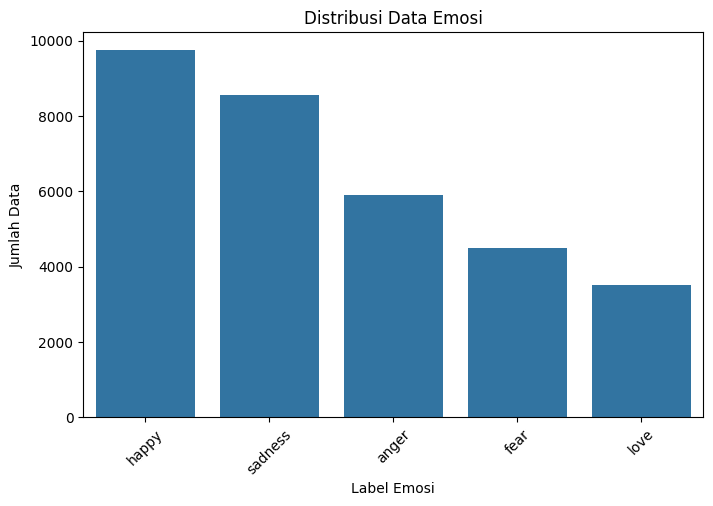

In [4]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='label',
    order=df['label'].value_counts().index
)

plt.title("Distribusi Data Emosi")
plt.xlabel("Label Emosi")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=45)

plt.show()

### **ANALISIS PANJANG TEKS**

In [5]:
df['text_length'] = df['tweet_clean'].apply(lambda x: len(str(x).split()))
print(df['text_length'].describe())

count    32183.000000
mean        19.717895
std         11.467042
min          1.000000
25%         10.000000
50%         18.000000
75%         27.000000
max        352.000000
Name: text_length, dtype: float64


### **ENCODING LABEL**

In [6]:
label_encoder = LabelEncoder()

df['label_enc'] = label_encoder.fit_transform(df['label'])

### **TEXT TOKENIZER**

In [7]:
vocab_size = 20000  # jumlah maksimal kata unik yang digunakan model
max_len = 150   # panjang maksimum sequence

# Tokenizer digunakan untuk mengubah kata menjadi indeks numerik, kata yang tidak dikenali model ditangani dengan <OOV>
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['tweet_clean'])

# Teks diubah menjadi sequence angka, digunakan padding dan truncating 'post' 
sequence = tokenizer.texts_to_sequences(df['tweet_clean'])
padded = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')

### **EMBEDDING MATRIX PRETRAINED FastText**
FastText digunakan untuk mengubah setiap kata menjadi representasi vektor yang memiliki makna. Dengan menggunakan file embedding saat training `cc.id.300.vec` dan sudah tersimpan di dalam model `.keras`

In [8]:
def get_embedding_matrix(tokenizer, vocab_size, embedding_dim=300):
    path_to_vec = 'cc.id.300.vec' 
    embeddings_index = {}

    needed_words = set(tokenizer.word_index.keys())
    
    with open(path_to_vec, 'r', encoding='utf-8') as f:
        next(f) 
        for line in f:
            values = line.rstrip().split(' ')
            word = values[0]
            
            if word not in needed_words:
                continue
            
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs

    word_index = tokenizer.word_index
    num_words = min(vocab_size, len(word_index) + 1)
    embedding_matrix = np.zeros((num_words, embedding_dim))
    
    for word, i in word_index.items():
        if i >= vocab_size:
            continue
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
    return embedding_matrix, num_words

embedding_dim = 300
matrix, actual_num_words = get_embedding_matrix(tokenizer, vocab_size, embedding_dim)

### **SPLIT DATASET**
Dataset dibagi menjadi `70% train`, `15% validation`, `15% test`

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    padded,
    df['label_enc'],
    test_size=0.3,
    random_state=42,
    stratify=df['label_enc']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

### **CUSTOM ATTENTION LAYER**

Fungsi utamanya untuk menghitung bobot perhatian untuk setiap token dalam teks. Token yang dianggap lebih penting akan memiliki bobot lebih besar.

---

Attention bekerja dengan cara:

1. Mengolah output GRU.
2. Menghitung skor perhatian setiap token.
3. Mengubah skor menjadi bobot menggunakan softmax.
4. Mengalikan bobot tersebut dengan representasi token.
5. Menghasilkan satu representasi akhir teks.

In [10]:
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    
    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], input_shape[-1]),
            initializer='glorot_uniform',
            trainable=True
        )
        
        self.u = self.add_weight(
            name="att_context_vector",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        
        super().build(input_shape)
    
    def call(self, inputs, mask=None):
        v = tf.tanh(tf.matmul(inputs, self.W))
        score = tf.matmul(v, self.u)
        
        if mask is not None:
            mask = tf.cast(mask, tf.float32)
            mask = tf.expand_dims(mask, axis=-1)
            score += (1.0 - mask) * -1e9
            
        weights = tf.nn.softmax(score, axis=1)  # softmax digunakan untuk menghasilkan bobot attention
        context = inputs*weights
        context = tf.reduce_sum(context, axis=1)    # menghasilkan representasi akhir teks berdasarkan attention weight
        
        return context
    
    def compute_mask(self, inputs, mask=None):
        return None

### **ARSITEKTUR MODEL**

In [11]:
num_classes = len(label_encoder.classes_)

inputs = tf.keras.Input(shape=(max_len,))

# Embedding Layer -> untuk mengubah token angka menjadi vektor dimensi 300 berdasarkan pretrained FastText
x = tf.keras.layers.Embedding(
    input_dim=actual_num_words,
    output_dim=embedding_dim,
    embeddings_initializer=tf.keras.initializers.Constant(matrix),
    trainable=False,
    mask_zero=True
)(inputs)

# SpatialDropout1D -> untuk mengurangi overfitting pada embedding 
x = tf.keras.layers.SpatialDropout1D(0.1)(x)

# Conv1D -> untuk menangkap pola lokal dalam teks, seperti kombinasi kata yang sering muncul bersamaan
x = tf.keras.layers.Conv1D(
    filters=128,
    kernel_size=5,
    activation='relu',
    padding='same'
)(x)

x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

# Bidirectional GRU -> untuk memahami urutan kata dari dua arah (depan ke belakang, belakang ke depan)
gru_out = tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(
        128,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.3
    )
)(x)

# Attention Layer -> untuk membuat model fokus pada kata-kata paling penting dalam teks.
att_out = AttentionLayer()(gru_out)

# Pooling Layer -> mengguankan 2 jenis pooling (GlobalMaxPooling1D dan GlobalAveragePooling1D)
pool_out = tf.keras.layers.GlobalMaxPooling1D()(gru_out)
avg_out = tf.keras.layers.GlobalAveragePooling1D()(gru_out)
merged = tf.keras.layers.Concatenate()([att_out, pool_out, avg_out])

# Dense Layer -> untuk mengolah fitur akhir sebelum diklasifikasikan kedalam kelas emosi
x = tf.keras.layers.Dense(128,
                          activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.0005))(merged) # L2 dan dropout digunakan untuk mengurangi overfitting

x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)

outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

c:\Users\snsv\Documents\Capstone Project\.env\lib\site-packages\keras\src\layers\layer.py:970: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 150, 300)  │  6,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 150, 300)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 150, 128)  │    192,128 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 75, 128)   │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 75, 256)   │    198,144 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 256)       │     65,792 │ bidirectional[0]… │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ bidirectional[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ bidirectional[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 768)       │          0 │ attention_layer[… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     98,432 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        645 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,555,653 (25.01 MB)

 Trainable params: 555,397 (2.12 MB)

 Non-trainable params: 6,000,256 (22.89 MB)

In [12]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
optimizer = tf.keras.optimizers.AdamW(learning_rate=5e-4, clipnorm=1.0)

In [13]:
train_dataset = (tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(10000).batch(32).prefetch(tf.data.AUTOTUNE))
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32)

train_accur = tf.keras.metrics.SparseCategoricalAccuracy()
val_accur = tf.keras.metrics.SparseCategoricalAccuracy()

train_loss = tf.keras.metrics.Mean()
val_loss = tf.keras.metrics.Mean()

### **CLASS WEIGHTS**

Class weight digunakan untuk menangani dataset yang tidak seimbang.
Jika ada kelas emosi yang jumlah datanya lebih sedikit, class weight akan memberikan bobot lebih besar pada kelas tersebut saat training.
Tujuannya agar model tidak terlalu bias ke kelas dengan jumlah data paling banyak.

In [14]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

### **TRAINING MODEL**

Training dilakukan menggunakan custom training loop dengan `tf.GradientTape`.

In [15]:
@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        y_pred = model(x, training=True)

        sample_weights = tf.gather(
            list(class_weights.values()),
            y
        )

        loss = loss_fn(y, y_pred, sample_weight=sample_weights)
        loss = tf.reduce_mean(loss)

    grads = tape.gradient(loss, model.trainable_variables)

    optimizer.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    train_accur.update_state(y, y_pred)
    train_loss.update_state(loss)

In [16]:
@tf.function
def val_step(x, y):
    y_pred = model(x, training=False)

    loss = tf.reduce_mean(
        loss_fn(y, y_pred)
    )

    val_accur.update_state(y, y_pred)
    val_loss.update_state(loss)

### **CUSTOM EARLYSTOP**

Fungsi early stopping untuk menghentikan training apabila validation loss tidak membaik setelah beberapa epoch.

Selain itu, custom early stopping juga menyimpan model terbaik ke file `best_model_nlp.keras`

In [17]:
class CustomEarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best = float('inf')
        self.wait = 0

    def step(self, val, model):
        if val < self.best: 
            self.best = val
            self.wait = 0
            model.save("best_model_nlp.keras")
            return False
        else:
            self.wait += 1
            return self.wait >= self.patience

In [18]:
log_dir = "logs/nlp"
writer = tf.summary.create_file_writer(log_dir)

In [19]:
best_val_loss = float('inf')
lr_patience = 2
lr_wait = 0
factor = 0.5
min_lr = 1e-6

### **TRAINING MODEL**

In [20]:
early_stop = CustomEarlyStopping(patience=5)
epochs = 30

for epoch in range(epochs):
    train_accur.reset_state()
    val_accur.reset_state()
    train_loss.reset_state()
    val_loss.reset_state()
    
    # Fine Tuning Embedding pada epoch ke-8, embedding layer mulai dibuka untuk dilatih kembali.
    if epoch == 8:
        print("fine tuning...")
        model.layers[1].trainable = True
        optimizer.learning_rate.assign(1e-5)
    
    for x_batch, y_batch in train_dataset:
        train_step(x_batch, y_batch)
        
    for x_batch, y_batch in val_dataset:
        val_step(x_batch, y_batch)
        
    train_acc_val = train_accur.result().numpy()
    val_acc_val = val_accur.result().numpy()
    current_val_loss = val_loss.result().numpy()
    
    print(f"epoch {epoch+1} - train acc {train_accur.result():.4f} - val acc: {val_accur.result():.4f} - train loss: {train_loss.result():.4f} - val loss: {val_loss.result():.4f}")
    
    with writer.as_default():
        tf.summary.scalar("train_accur", train_acc_val, step=epoch)
        tf.summary.scalar("val_accur", val_acc_val, step=epoch)
        tf.summary.scalar("train_loss", train_loss.result(), step=epoch)
        tf.summary.scalar("val_loss", val_loss.result(), step=epoch)
        
    if current_val_loss < best_val_loss:
        best_val_loss =current_val_loss
        lr_wait = 0
    else:
        lr_wait+=1
        
        # Learning rate diturunkan menjadi lebih kecil agar proses fine tuning lebih stabil.
        if lr_wait >= lr_patience:
            old_lr = optimizer.learning_rate.numpy()
            new_lr = max(old_lr*factor, min_lr)
            
            optimizer.learning_rate.assign(new_lr)
            print(f"lr turun {old_lr:.6f} - {new_lr:.6f}")
            
            lr_wait = 0
        
    if early_stop.step(current_val_loss, model):
        print("early stop")
        break

c:\Users\snsv\Documents\Capstone Project\.env\lib\site-packages\keras\src\layers\layer.py:970: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


epoch 1 - train acc 0.4590 - val acc: 0.5797 - train loss: 1.2938 - val loss: 1.0774
epoch 2 - train acc 0.6372 - val acc: 0.6640 - train loss: 0.9551 - val loss: 0.9010
epoch 3 - train acc 0.6929 - val acc: 0.6932 - train loss: 0.8260 - val loss: 0.8552
epoch 4 - train acc 0.7199 - val acc: 0.7292 - train loss: 0.7469 - val loss: 0.7588
epoch 5 - train acc 0.7409 - val acc: 0.7394 - train loss: 0.6841 - val loss: 0.7203
epoch 6 - train acc 0.7686 - val acc: 0.7303 - train loss: 0.6231 - val loss: 0.7463
epoch 7 - train acc 0.7850 - val acc: 0.7599 - train loss: 0.5725 - val loss: 0.6812
epoch 8 - train acc 0.7995 - val acc: 0.7676 - train loss: 0.5281 - val loss: 0.6645
fine tuning...
epoch 9 - train acc 0.8364 - val acc: 0.7798 - train loss: 0.4359 - val loss: 0.6255
epoch 10 - train acc 0.8387 - val acc: 0.7794 - train loss: 0.4224 - val loss: 0.6238
epoch 11 - train acc 0.8430 - val acc: 0.7798 - train loss: 0.4180 - val loss: 0.6218
epoch 12 - train acc 0.8466 - val acc: 0.7787 - 

In [21]:
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
    
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

### **SAVE BEST MODEL**

Pada file `best_model_nlp.keras` telah menyimpan format:
1. arsitektur model
2. bobot model
3. konfigurasi training
4. optimizer state

In [22]:
best_model = tf.keras.models.load_model(
    "best_model_nlp.keras",
    custom_objects={
        'AttentionLayer': AttentionLayer
    }
)

### **MODEL EVALUATION**

In [23]:
y_pred_prob = best_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

print("F1 score:", f1_score(y_test, y_pred, average='weighted'))

151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step
              precision    recall  f1-score   support

       anger       0.79      0.77      0.78       884
        fear       0.81      0.84      0.82       674
       happy       0.81      0.79      0.80      1461
        love       0.68      0.73      0.70       527
     sadness       0.76      0.76      0.76      1282

    accuracy                           0.78      4828
   macro avg       0.77      0.78      0.77      4828
weighted avg       0.78      0.78      0.78      4828

F1 score: 0.7775474400940343


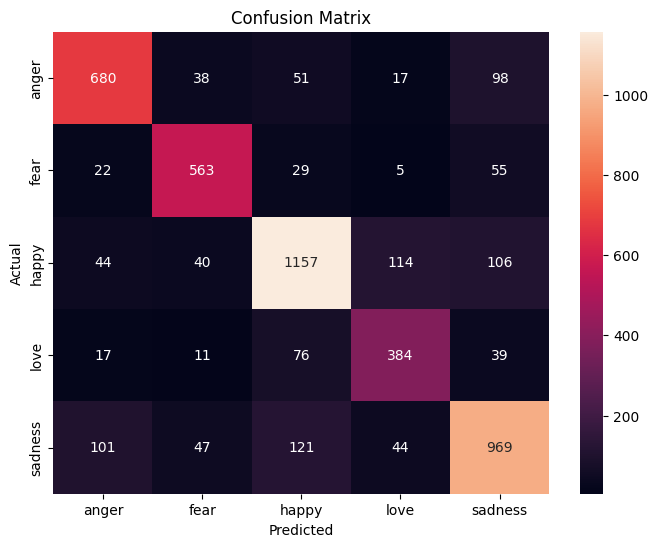

In [24]:
y_pred = np.argmax(y_pred_prob, axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### **PREDICT EMOTION**

Fungsi ini digunakan untuk memprediksi emosi dari satu teks pendek.

---

Alurnya:
1. menerima teks input
2. mengubah teks menjadi sequence menggunakan tokenizer
3. melakukan padding hingga panjang 150 token
4. melakukan prediksi menggunakan model
5. mengambil label dengan probabilitas tertinggi
6. menggembalikan label emosi dan seluruh probabilitas kelas 

In [25]:
def predict_emotion(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    pred = best_model.predict(pad)
    label = label_encoder.inverse_transform([np.argmax(pred)])

    return label[0], pred[0]

### **FUNGSI SPLIT_TEXT**

Digunakan untuk membagi teks panjang menjadi beberapa bagian kecil (chunk).

Fungsi ini digunakan karena model hanya menerima input maksimal 150 token (karena bergantung pada dataset yang digunakan untuk training).

Jika user menulis diary panjang, teks akan dipotong menjadi beberapa bagian (chunk) agar tetap bisa diproses model.

---

### Parameter:

`chunk_size=150` -> setiap chunk maksimal 150 kata.

`overlap=35` -> antar chunk memiliki 35 kata yang sama untuk menjaga konteks agar tidak hilang.

In [26]:
def split_text(text, chunk_size=150, overlap=35):
    words = text.split()
    chunks = []
    step = chunk_size-overlap

    for i in range(0, len(words), step):
        chunk = words[i:i+chunk_size]
        if len(chunk) > 0:
            chunks.append(" ".join(chunk))

    return chunks

### **FUNGSI PREDIKSI TEKS PANJANG**

In [27]:
def predict_long_text(text):
    chunks = split_text(text)
    sequences = tokenizer.texts_to_sequences(chunks)
    
    padded = pad_sequences(
        sequences,
        maxlen=max_len,
        padding='post',
        truncating='post'
    )

    preds = best_model.predict(
        padded,
        verbose=0
    )

    labels = []
    print("="*50)

    for i, pred in enumerate(preds):
        label = label_encoder.inverse_transform(
            [np.argmax(pred)]
        )[0]

        confidence = np.max(pred)
        labels.append(label)
        # confidences.append(confidence)

        print(
            f"chunk {i+1}: "
            f"{label} "
            f"({confidence:.3f})"
        )
    print("="*50)

    # Menggunakan Average Probability -> probabilitas dari semua chunk di rata-ratakan
    final_probs = np.mean(preds, axis=0)

    # Majority Voting -> mengghitung label yang paling sering muncul dari semua chunk
    vote_counter = Counter(labels)
    majority_label = vote_counter.most_common(1)[0][0]
    
    prob_label=label_encoder.inverse_transform(
        [np.argmax(final_probs)]
    )[0]
    
    if vote_counter[majority_label] >= 3: # Jika label yang muncul lebih dari 3x, maka label tersebut dianggap sebagai emosi dominan
        final_label = majority_label
    else:
        final_label = prob_label
    
    return final_label, final_probs

### **INFERENCE**

In [28]:
"""Selain menampilkan satu emosi akhir, juga dibuat menampilkan dua emosi dengan probabilitas tertinggi.
Karena emosi sering bersifat campuran atau ambigu. Dari contoh inference, model memprediksi anger sebagai emosi
utama, tetapi sadness juga cukup tinggi. Artinya teks user kemungkinan mengandung emosi campuran atara sedih dan marah.
"""


text = "hari ini aku merasa seperti orang gila"

label, probs = predict_long_text(text)

top2_emosi = np.argsort(probs)[-2:][::-1]
print("\nEmosi yang dirasa saat ini:")

for idx in top2_emosi:
    emotion = label_encoder.classes_[idx]
    probability = probs[idx]
    
    print(f"{emotion}: {probability:.3f}")

print("\nPrediksi akhir:", label)

chunk 1: anger (0.422)

Emosi yang dirasa saat ini:
anger: 0.422
sadness: 0.346

Prediksi akhir: anger
